In [1]:
import sys
sys.path.append('../utils')
from utils_models import *
from scipy.optimize import minimize

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

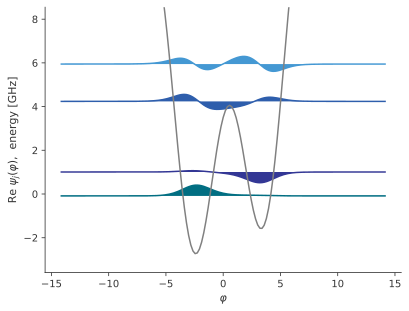

In [2]:
EJ = 4
EC = 4/5.9
EL = 4/29.2
fluxonium1 = scqubits.Fluxonium(EJ=EJ,
                        EC=EC,
                        EL=EL,
                        flux=0,cutoff=110,
                        truncated_dim=12)

fluxonium2 =  scqubits.Fluxonium(EJ=4,
                        EC=4/4,
                        EL=4/10,
                        flux=0.42,cutoff=110,
                        truncated_dim=12)

system = FluxoniumFluxoniumSystem(
    fluxonium1  = fluxonium1,
    fluxonium2 = fluxonium2,
    computaional_states = '1,2',
    g_strength = 0.01,
    )
fluxonium2.plot_wavefunction(which=[0,1,2,3])


In [5]:
system.evals[system.product_to_dressed[(0,3)]]-system.evals[system.product_to_dressed[(0,2)]], \
system.evals[system.product_to_dressed[(1,3)]]-system.evals[system.product_to_dressed[(1,2)]], \
system.evals[system.product_to_dressed[(2,3)]]-system.evals[system.product_to_dressed[(2,2)]]

(1.7081494055298272, 1.7081759253813837, 1.7081547124409049)

# Let's try EIT

In [3]:
initial_states = [
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(0,0)]),
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(1,0)]),
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(2,0)])
]

e_ops = []
for ql in range(3):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))

# Get the Raman pi pulse parameters
op = system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)
# Omega_p = 1/200
# Omega_c = Omega_p * 5
# Delta = 0.01
# length = 1/Omega_p



# aera_probe = np.pi  * 0.2
# amplitude_g02 = aera_probe/( length * abs(op[system.product_to_dressed[(0,2)],  system.product_to_dressed[(0,0)]])   )
# amplitude_g21 = aera_probe/( length * abs(op[system.product_to_dressed[(0,2)],  system.product_to_dressed[(0,1)]])   )

# amplitude_e02 = aera_probe/( length * abs(op[system.product_to_dressed[(1,2)],  system.product_to_dressed[(1,0)]])   )
# amplitude_e21 = aera_probe/( length * abs(op[system.product_to_dressed[(1,2)],  system.product_to_dressed[(1,1)]])   )

# amplitude_f02 = aera_probe/( length * abs(op[system.product_to_dressed[(2,2)],  system.product_to_dressed[(2,0)]])   )
# amplitude_f21 = aera_probe/( length * abs(op[system.product_to_dressed[(2,2)],  system.product_to_dressed[(2,1)]])   )

# amplitude_g02, amplitude_g21,     amplitude_e02, amplitude_e21,     amplitude_f02, amplitude_f21

# This is a Raman drive without EIT (can be updated to STIRAP)

 Total run time:  25.65s*] Elapsed 25.65s / Remaining 00:00:00:00[*******  29%           ] Elapsed 1.69s / Remaining 00:00:00:04
 Total run time:  25.86s*] Elapsed 25.86s / Remaining 00:00:00:00
 Total run time:  27.34s*] Elapsed 27.34s / Remaining 00:00:00:00


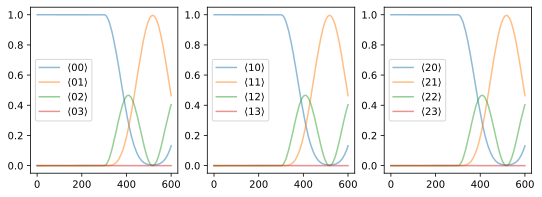

In [8]:
length = 600
tlist = np.linspace(0,length,int(length))
Delta = 0

results = system.run_qutip_mesolve_parrallel(
        initial_states = initial_states,
        tlist = tlist,
        drive_terms = [
            # EIT drive
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d':system.evals[system.product_to_dressed[(1,3)]]-system.evals[system.product_to_dressed[(1,2)]] - Delta/(2*np.pi),
                    'amp': 0.0/(2*np.pi),
                    't_rise':  1e-5,
                    't_square': 1000,
                    't_start': 0
                  },
                ),

            # Raman first arm
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=second_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d1':system.evals[system.product_to_dressed[(2,2)]] - system.evals[system.product_to_dressed[(2,0)]] +Delta/(2*np.pi),
                    'amp1':0.007218540621271747,
                    't_rise1': 1e-5,
                    't_square1': 1000,
                    't_start1': 300
                  },
                ),

            # Raman second arm
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=third_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d2':system.evals[system.product_to_dressed[(2,2)]] - system.evals[system.product_to_dressed[(2,1)]] + Delta/(2*np.pi),
                    'amp2': 0.0101,
                    't_rise2': 1e-5,
                    't_square2': 1000,
                    't_start2': 300
                  },
                )
            ],
        c_ops = None,
        e_ops = e_ops,
        post_processing = []
    )

fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()

# Demonstrating EIT (although not state-selective)

 Total run time:  28.71s*] Elapsed 28.71s / Remaining 00:00:00:00 [*********79%******     ] Elapsed 22.81s / Remaining 00:00:00:06
 Total run time:  28.90s*] Elapsed 28.90s / Remaining 00:00:00:00
 Total run time:  28.96s*] Elapsed 28.96s / Remaining 00:00:00:00


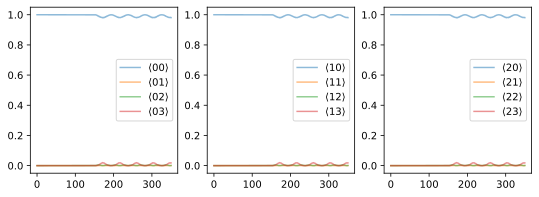

In [7]:
length = 350
tlist = np.linspace(0,length,int(length))
Delta = 0

results = system.run_qutip_mesolve_parrallel(
        initial_states = initial_states,
        tlist = tlist,
        drive_terms = [
            # EIT drive
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d':system.evals[system.product_to_dressed[(2,3)]]-system.evals[system.product_to_dressed[(2,2)]] - Delta/(2*np.pi),
                    'amp': 0.1,
                    't_rise':  100,
                    't_square': 1000,
                    't_start': 0
                  },
                ),

            # Raman first arm
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=second_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d1':system.evals[system.product_to_dressed[(2,2)]] - system.evals[system.product_to_dressed[(2,0)]] +Delta/(2*np.pi),
                    'amp1':0.007218540621271747,
                    't_rise1': 1e-5,
                    't_square1': 1000,
                    't_start1': 150
                  },
                ),

            # Raman second arm
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=third_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d2':system.evals[system.product_to_dressed[(2,2)]] - system.evals[system.product_to_dressed[(2,1)]] + Delta/(2*np.pi),
                    'amp2': 0.0101,
                    't_rise2': 1e-5,
                    't_square2': 1000,
                    't_start2': 150
                  },
                )
            ],
        c_ops = None,
        e_ops = e_ops,
        post_processing = []
    )

fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()

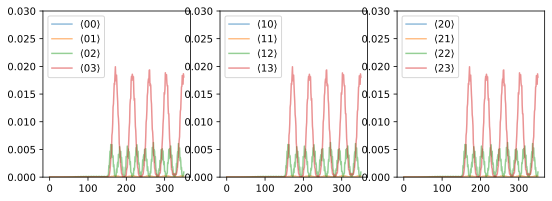

In [8]:
fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()
    axes[i].set_ylim(0,0.03)


# Next we optimize $\chi_0^{\omega_{23}} \ne \chi_1^{\omega_{23}} \ne \chi_2^{\omega_{23}}$

In [19]:
EJ = 4
EC = 4/5.9
EL = 4/29.2
fluxonium1 = scqubits.Fluxonium(EJ=EJ,
                        EC=EC,
                        EL=EL,
                        flux=0,cutoff=110,
                        truncated_dim=20)
freq = {
    'g0g2':[],
    'e0e2':[],
    'f0f2':[],

    'g1g2':[],
    'e1e2':[],
    'f1f2':[],

    'g2g3':[],
    'e2e3':[],
    'f2f3':[]
}

# me = {
#     'g1g2':[],
#     'e1e2':[],
#     'f1f2':[]
# }

bare_freq = []

EJ_list = np.linspace(2,6,100)
for f_EJ in tqdm(EJ_list):
    fluxonium2 =  scqubits.Fluxonium(EJ=f_EJ,
                        EC=4/4,
                        EL=4/8,
                        flux=0.42,cutoff=110,
                        truncated_dim=20)

    system = FluxoniumFluxoniumSystem(
        fluxonium1  = fluxonium1,
        fluxonium2 = fluxonium2,
        computaional_states = '1,2',
        g_strength = 0.1,
        )

    def dressed_ener(ql,ol):
        return system.evals[system.product_to_dressed[(ql,ol)]]
    # op = system.hilbertspace.op_in_dressed_eigenbasis(fluxonium2.n_operator)

    bare_freq.append(fluxonium2.eigenvals()[3]-fluxonium2.eigenvals()[2])


    freq['g0g2'].append(dressed_ener(0,2)-dressed_ener(0,0))
    freq['e0e2'].append(dressed_ener(1,2)-dressed_ener(1,0))
    freq['f0f2'].append(dressed_ener(2,2)-dressed_ener(2,0))

    freq['g1g2'].append(dressed_ener(0,2)-dressed_ener(0,1))
    freq['e1e2'].append(dressed_ener(1,2)-dressed_ener(1,1))
    freq['f1f2'].append(dressed_ener(2,2)-dressed_ener(2,1))

    freq['g2g3'].append(dressed_ener(0,3)-dressed_ener(0,2))
    freq['e2e3'].append(dressed_ener(1,3)-dressed_ener(1,2))
    freq['f2f3'].append(dressed_ener(2,3)-dressed_ener(2,2))


    # me['g1g2'].append(abs(op[system.product_to_dressed[(0,1)],  system.product_to_dressed[(0,2)]]))
    # me['e1e2'].append(abs(op[system.product_to_dressed[(1,1)],  system.product_to_dressed[(1,2)]]))
    # me['f1f2'].append(abs(op[system.product_to_dressed[(2,1)],  system.product_to_dressed[(2,2)]]))


100%|██████████| 100/100 [01:19<00:00,  1.26it/s]


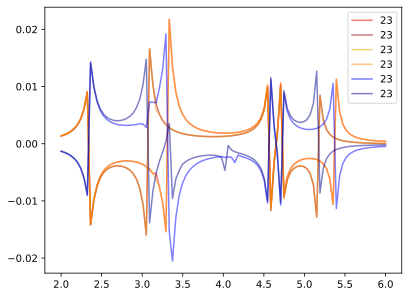

In [26]:
plt.plot(EJ_list,np.array(freq['g0g2'])-np.array(freq['e0e2']),label='23',color='red',alpha=0.5)
plt.plot(EJ_list,np.array(freq['f0f2'])-np.array(freq['e0e2']),label='23',color='darkred',alpha=0.5)

plt.plot(EJ_list,np.array(freq['g1g2'])-np.array(freq['e1e2']),label='23',color='orange',alpha=0.5)
plt.plot(EJ_list,np.array(freq['f1f2'])-np.array(freq['e1e2']),label='23',color='darkorange',alpha=0.5)

plt.plot(EJ_list,np.array(freq['g2g3'])-np.array(freq['e2e3']),label='23',color='blue',alpha=0.5)
plt.plot(EJ_list,np.array(freq['f2f3'])-np.array(freq['e2e3']),label='23',color='darkblue',alpha=0.5)
# plt.xlim(4.5,5.5)
plt.legend()

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

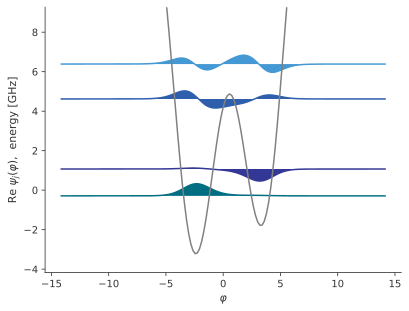

In [18]:
fluxonium2 =  scqubits.Fluxonium(EJ=4.8,
                        EC=4/4,
                        EL=4/8,
                        flux=0.42,cutoff=110,
                        truncated_dim=12)

fluxonium2.plot_wavefunction(which=[0,1,2,3])

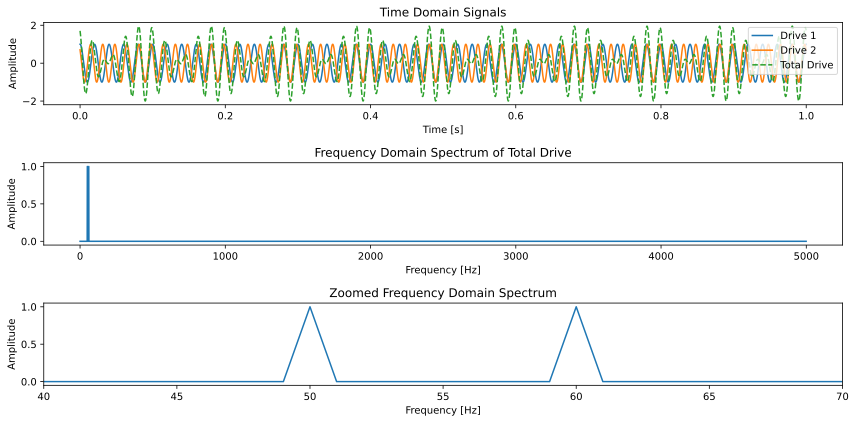

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Define the sampling parameters
sampling_rate = 10000  # Sampling rate in Hz
T = 1.0 / sampling_rate  # Sampling interval
duration = 1.0  # Duration in seconds
t = np.arange(0, duration, T)  # Time vector

# Define the drive frequencies and phases
f1 = 50  # Drive frequency 1 in Hz
f2 = 60  # Drive frequency 2 in Hz
omega_1 = 2 * np.pi * f1
omega_2 = 2 * np.pi * f2
phi_1 = 0  # Phase 1
phi_2 = np.pi / 4  # Phase 2

# Define the drive amplitudes
A = 1.0
B = 1.0

# Create the signals
V1 = A * np.cos(omega_1 * t + phi_1)
V2 = B * np.cos(omega_2 * t + phi_2)
V_total = V1 + V2

# Perform the FFT
N = len(t)
yf = fft(V_total)
xf = fftfreq(N, T)[:N//2]

# Plot the time domain signals
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(t, V1, label='Drive 1')
plt.plot(t, V2, label='Drive 2')
plt.plot(t, V_total, label='Total Drive', linestyle='dashed')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.title('Time Domain Signals')

# Plot the frequency domain signals
plt.subplot(3, 1, 2)
plt.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Frequency Domain Spectrum of Total Drive')

# Zoom in around the frequencies of interest
plt.subplot(3, 1, 3)
plt.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.xlim(f1 - 10, f2 + 10)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Zoomed Frequency Domain Spectrum')

plt.tight_layout()
plt.show()
